In [1]:
import sys
sys.path.append('..')
from experiment_utils import read_config_file, get_site_splits
from utils import get_project_dir
from eval_utils import compare_aligned_data

import numpy as np
import os
import rasterio

import sklearn.metrics
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

In [2]:
project_dir = '/n/tambe_lab/Everyone/tree_mapping'
data_dir = os.path.join('..', 'data')
outputs_dir = '/n/tambe_lab/Everyone/model_output/subsetted_train_sites'
resolution = 10
split_seed = 10
pred_padding = 40 # defined by how we cropped the satellite imagery to the Karingani sites
lidar_coarsened_dir = f'{project_dir}/lidar_by_site_32736_{resolution}m'
sites = sorted([x for x in os.listdir(lidar_coarsened_dir) if not x.startswith('.')])
reference_maps = ['ETH', 'GLAD', 'META', 'PAULS']
random_trial_seeds = np.arange(10)

# use best model for comparison
models_fcn = [f'local_only_models/128_filters/{x}' for x in ['12_channels']]
models = models_fcn

results_by_site = {x: {} for x in reference_maps + models}


In [3]:
# get results
for reference_map in reference_maps:
    labels = []
    preds = []
    reference_map_by_site_dir = f'{project_dir}/existing_reference_data/{reference_map.lower()}_maps_per_site_{resolution}m'

    for split_number in range(4):
        labels_by_split = []
        preds_by_split = []
        test_sites = get_site_splits(split_seed, data_dir = data_dir)[split_number]['test_sites']
        
        for site in test_sites:
            with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
                site_labels = file.read().ravel()
                labels = np.append(labels, site_labels)
                labels_by_split = np.append(labels_by_split, site_labels)

            with rasterio.open(f'{reference_map_by_site_dir}/{reference_map}_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
                site_preds = file.read().ravel()
                preds = np.append(preds, site_preds)
                preds_by_split = np.append(preds_by_split, site_preds)

            results_by_site[reference_map][site] = compare_aligned_data(site_labels, site_preds, return_vals=True)

results_print_models_by_seed = pd.DataFrame()
for trial in [0]:
    for model in models:
        labels = []
        preds = []
        model_output_dir = f'{outputs_dir}/{model}'

        for split_number in range(4):
            labels_by_split = []
            preds_by_split = []
            test_sites = get_site_splits(split_seed, data_dir = data_dir)[split_number]['test_sites']

            for site in test_sites:
                with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
                    site_labels = file.read().ravel()
                    labels = np.append(labels, site_labels)
                    
                with rasterio.open(f'{model_output_dir}/12_train_sites/seed_{trial}/preds_{site}.tif') as file: # opens prediction tiff
                    site_preds = file.read()[:, pred_padding:-pred_padding, pred_padding:-pred_padding].ravel()
                    preds = np.append(preds, site_preds)

                results_by_site[model][site] = compare_aligned_data(site_labels, site_preds, return_vals=True)
   

# get all preds and plot distributions

In [4]:
model_names = ['ETH']

methods_compare = ['ETH',  'META', 'GLAD', 'local_only_models/128_filters/12_channels']
#results_by_split_df_condensed = results_by_split_df[results_by_split_df['map_type'].apply(lambda x: x in methods_compare)]

y_key = 'rmse'
metric_labels = {'mae': "Mean Absolute Error (m)", 'rmse': "Root Mean Squared Error (m)"}

label_names_dict = {'ETH':'ETH', 
                    'GLAD':'GLAD', 
                    'META':'Meta', 
                    'local_only_models/128_filters/3_channels': 'FCN 3 channels (ours)',
                   'local_only_models/128_filters/4_channels': 'FCN 4 channels (ours)',
                   'local_only_models/128_filters/12_channels': 'locally trained FCN (ours)',
                   'local_only_models/128_filters/15_channels': 'FCN 15 channels (ours)'}


In [5]:
best_model = f'local_only_models/128_filters/12_channels'

labels_by_model = {x: [] for x in reference_maps + [best_model,]}
preds_by_model = {x: [] for x in reference_maps + [best_model,]}

for site in sites:
    for model in reference_maps + [best_model,]:
        # data mask is different if the map outputs are NaN
        data_mask = results_by_site[model][site]['data_mask']
        labels_by_model[model].append(results_by_site[model][site]['labels'][data_mask])
        preds_by_model[model].append(results_by_site[model][site]['preds'][data_mask])
        

In [6]:
labels_ETH = np.hstack(labels_by_model['ETH'])
labels_GLAD = np.hstack(labels_by_model['GLAD'])
labels_META = np.hstack(labels_by_model['META'])
labels_PAULS = np.hstack(labels_by_model['PAULS'])
labels_ours = np.hstack(labels_by_model[best_model])

preds_ETH = np.hstack(preds_by_model['ETH'])
preds_GLAD = np.hstack(preds_by_model['GLAD'])
preds_META = np.hstack(preds_by_model['META'])
preds_PAULS = np.hstack(preds_by_model['PAULS'])
preds_ours =  np.hstack(preds_by_model[best_model])

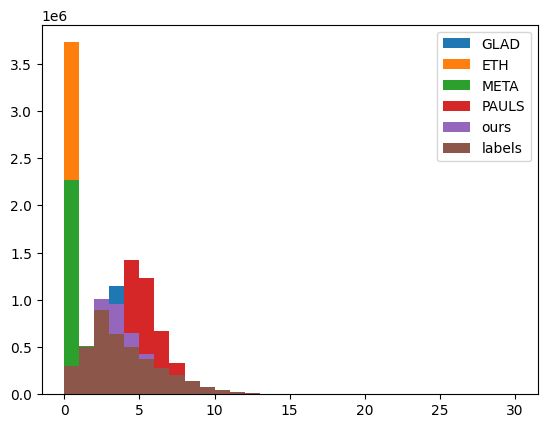

In [7]:
plt.hist(preds_GLAD, bins=30, range=(0,30),label='GLAD');
plt.hist(preds_ETH, bins=30, range=(0,30),label='ETH');
plt.hist(preds_META, bins=30, range=(0,30),label='META');
plt.hist(preds_PAULS, bins=30, range=(0,30),label='PAULS');
plt.hist(preds_ours,  bins=30, range=(0,30),label='ours');
plt.hist(labels_ours,  bins=30, range=(0,30),label='labels');
plt.legend()

In [8]:
hm_ours = np.zeros((31,31))
hm_GLAD = np.zeros((31,31))
hm_ETH = np.zeros((31,31))
hm_META = np.zeros((31,36))
hm_PAULS = np.zeros((31,31))


for pred, label in zip(preds_ours.round().astype(int), labels_ours.round().astype(int)):
    pred = pred.clip(0,30) 
    hm_ours[label, pred] +=1
    
for pred, label in zip(preds_GLAD.round().astype(int), labels_GLAD.round().astype(int)):
    hm_GLAD[label, pred] +=1
    
for pred, label in zip(preds_ETH.round().astype(int), labels_ETH.round().astype(int)):
    hm_ETH[label, pred] +=1
    
for pred, label in zip(preds_META.round().astype(int), labels_META.round().astype(int)):
    hm_META[label, pred] +=1
    
    
for pred, label in zip(preds_PAULS.round().astype(int), labels_PAULS.round().astype(int)):
    hm_PAULS[label, pred] +=1

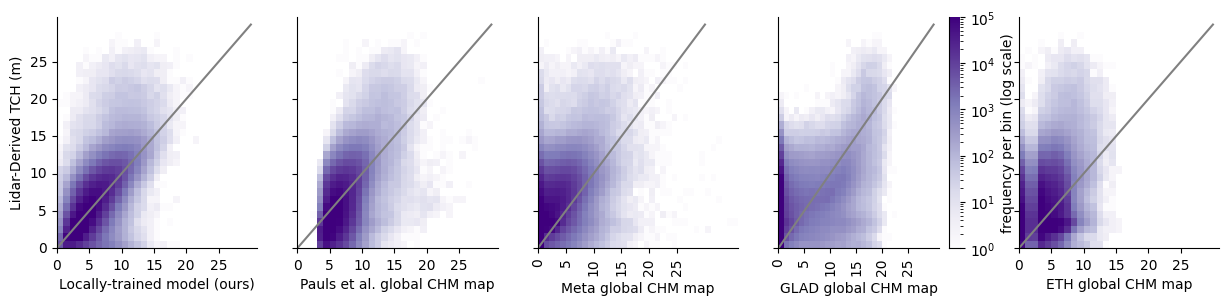

In [9]:
from matplotlib.colors import LogNorm, Normalize

fig, ax = plt.subplots(1,5, figsize=(15,3), sharex=False, sharey=True)
sns.heatmap(hm_ours,cmap='Purples', 
            norm=LogNorm(vmin=1, vmax=1e5), 
            ax=ax[0], cbar=False)
sns.heatmap(hm_PAULS,cmap='Purples',norm=LogNorm(vmin=1, vmax=1e5),  ax=ax[1], cbar=False)

sns.heatmap(hm_META,cmap='Purples',norm=LogNorm(vmin=1, vmax=1e5),  ax=ax[2], cbar=False)
sns.heatmap(hm_ETH,cmap='Purples', norm=LogNorm(vmin=1, vmax=1e5), ax=ax[3], cbar=True, cbar_kws={'label':'frequency per bin (log scale)'})

sns.heatmap(hm_GLAD,cmap='Purples',norm=LogNorm(vmin=1, vmax=1e5),  ax=ax[4], cbar=False)

names = ['Locally-trained model (ours)', 'Pauls et al. global CHM map', 'Meta global CHM map','GLAD global CHM map', 'ETH global CHM map']

for i, ax_this in enumerate(ax):
    ax_this.set_xticks(np.arange(0,30,5), np.arange(0,30,5))
    ax_this.set_yticks(np.arange(0,30,5), np.arange(0,30,5))
    ax_this.set_xlabel(f'{names[i]}')
    ax_this.plot([0,30],[0,30], color='gray', 
                 #label='diagonal (preds=labels)'
                )

#plt.legend()
    
ax[0].set_ylabel('Lidar-Derived TCH (m)')
ax[0].invert_yaxis()
sns.despine()

plt.savefig(f'../figures/qualitative_insets_{site}.png', bbox_inches='tight')